Building neural networks from absolute scratch is the best way to demystify how modern AI works. The abstraction layers in PyTorch or TensorFlow are fantastic for production, but they hide the fundamental calculus and linear algebra that make the whole system learn.

When you are **orchestrating complex, multi-agent workflows or fine-tuning specialized vision models** to run on constrained hardware, understanding these low-level gradients is what allows you to manipulate memory, debug vanishing gradients, and optimize model quantization effectively.

Here is a complete, purely mathematical **3-layer Multi-Layer Perceptron (MLP)** built strictly with Python and NumPy. We will break down the math, the code, and the underlying logic of how this scales up to agentic systems.

| Concept               | Why Important             |
| --------------------- | ------------------------- |
| Matrix multiplication | Core of neural networks   |
| Activation functions  | Add non-linearity         |
| ReLU                  | Fast/simple activation    |
| GeLU                  | Used in transformers/LLMs |
| Gradients             | Learning signal           |
| Backpropagation       | Training mechanism        |
| Weight update         | Optimization              |
| Loss function         | Measures error            |


# NumPy Implementation

NumPy handles arrays in contiguous blocks of C-memory. When you call a function like np.dot(), Python isn't calculating the math; it is handing the operation off to highly optimized C or Fortran libraries (like BLAS/LAPACK) that compute the matrix operations in parallel.

In [1]:
import numpy as np

In [4]:
import numpy as np

class MLP:
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        # He Initialization: Scales starting weights to prevent vanishing/exploding gradients
        self.W1 = np.random.randn(hidden1_size, input_size) * np.sqrt(2. / input_size)
        self.b1 = np.zeros((hidden1_size, 1))
        
        self.W2 = np.random.randn(hidden2_size, hidden1_size) * np.sqrt(2. / hidden1_size)
        self.b2 = np.zeros((hidden2_size, 1))
        
        self.W3 = np.random.randn(output_size, hidden2_size) * np.sqrt(2. / hidden2_size)
        self.b3 = np.zeros((output_size, 1))
        
    # --- ACTIVATION FUNCTIONS ---
    def relu(self, Z):
        return np.maximum(0, Z)
        
    def relu_derivative(self, Z):
        return (Z > 0).astype(float)
        
    def gelu(self, Z):
        # The Tanh Approximation of GeLU
        self.z_inner = np.sqrt(2 / np.pi) * (Z + 0.044715 * Z**3)
        return 0.5 * Z * (1 + np.tanh(self.z_inner))
        
    def gelu_derivative(self, Z):
        # The mathematical derivative of the Tanh Approximation
        z_inner = np.sqrt(2 / np.pi) * (Z + 0.044715 * Z**3)
        tanh_z = np.tanh(z_inner)
        dz_inner = np.sqrt(2 / np.pi) * (1 + 3 * 0.044715 * Z**2)
        
        # 0.5 * (1 + tanh(z)) + 0.5 * Z * sech^2(z) * dz/dx
        return 0.5 * (1 + tanh_z) + 0.5 * Z * (1 - tanh_z**2) * dz_inner

    def sigmoid(self, Z):
        Z = np.clip(Z, -500, 500) # Prevents math overflow errors
        return 1 / (1 + np.exp(-Z))
        
    # --- CORE LOGIC ---
    def forward(self, X, activation="gelu"):
        self.X = X # Save input for backward pass
        
        # Layer 1 (ReLU)
        self.Z1 = np.dot(self.W1, X) + self.b1
        self.A1 = self.relu(self.Z1)
        
        # Layer 2 (GeLU or ReLU)
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        if activation == "gelu":
            self.A2 = self.gelu(self.Z2)
        else:
            self.A2 = self.relu(self.Z2)
            
        # Layer 3 / Output (Sigmoid for binary classification)
        self.Z3 = np.dot(self.W3, self.A2) + self.b3
        self.A3 = self.sigmoid(self.Z3)
        
        return self.A3
        
    def backward(self, Y, activation="gelu"):
        m = Y.shape[1] # Number of training examples in the batch
        
        # 1. Output layer error 
        # (Derivative of Binary Cross Entropy + Sigmoid simplifies cleanly to A - Y)
        dZ3 = self.A3 - Y
        dW3 = (1 / m) * np.dot(dZ3, self.A2.T)
        db3 = (1 / m) * np.sum(dZ3, axis=1, keepdims=True)
        
        # 2. Hidden Layer 2 error
        dA2 = np.dot(self.W3.T, dZ3)
        if activation == "gelu":
            dZ2 = dA2 * self.gelu_derivative(self.Z2)
        else:
            dZ2 = dA2 * self.relu_derivative(self.Z2)
            
        dW2 = (1 / m) * np.dot(dZ2, self.A1.T)
        db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
        
        # 3. Hidden Layer 1 error
        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        
        dW1 = (1 / m) * np.dot(dZ1, self.X.T)
        db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
        
        return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}

    def update_params(self, grads, learning_rate):
        # Gradient Descent: Step in the opposite direction of the gradient
        self.W1 -= learning_rate * grads["dW1"]
        self.b1 -= learning_rate * grads["db1"]
        self.W2 -= learning_rate * grads["dW2"]
        self.b2 -= learning_rate * grads["db2"]
        self.W3 -= learning_rate * grads["dW3"]
        self.b3 -= learning_rate * grads["db3"]

### Training

In [5]:
# 1. Generate Non-Linear Mock Data (Concentric Circles)
def generate_data(num_samples=1000):
    np.random.seed(42)
    # Generate random (x, y) coordinates
    X = np.random.randn(2, num_samples) * 1.5 
    
    # Calculate distance from origin
    radius = np.linalg.norm(X, axis=0, keepdims=True)
    
    # Class 1 if inside a radius of 1.5, Class 0 if outside
    Y = (radius < 1.5).astype(int)
    
    # Add some noise to make it harder
    X += np.random.randn(2, num_samples) * 0.2
    
    return X, Y

In [42]:
# 2. Binary Cross-Entropy Loss
def compute_loss(Y, Y_hat):
    m = Y.shape[1]
    
    # Clip predictions to prevent log(0) explosions
    Y_hat = np.clip(Y_hat, 1e-15, 1 - 1e-15)
    
    # Vectorized BCE Loss
    loss = -(1 / m) * np.sum(Y * np.log(Y_hat) + (1 - Y) * np.log(1 - Y_hat))
    return loss

In [43]:
# 3. The Training Loop
def train(model, X, Y, epochs=2500, learning_rate=0.05, activation="gelu"):
    print(f"Starting training for {epochs} epochs using {activation.upper()}...")
    
    for epoch in range(epochs):
        # A. Forward Pass (Predict)
        Y_hat = model.forward(X, activation=activation)
        
        # B. Calculate Loss
        loss = compute_loss(Y, Y_hat)
        
        # C. Backward Pass (Calculate Gradients)
        grads = model.backward(Y, activation=activation)
        
        # D. Update Weights (Gradient Descent)
        model.update_params(grads, learning_rate)
        
        # E. Logging
        if epoch % 500 == 0:
            # Calculate accuracy
            predictions = (Y_hat > 0.5).astype(int)
            accuracy = np.mean(predictions == Y) * 100
            print(f"Epoch {epoch:4d} | Loss: {loss:.4f} | Accuracy: {accuracy:.1f}%")

In [44]:
X_train , Y_train = generate_data(num_samples=800)
model = MLP(input_size=2, hidden1_size=16, hidden2_size=16, output_size=1)


In [45]:
train(model, X_train, Y_train, epochs=3000, learning_rate=0.1, activation="gelu")

Starting training for 3000 epochs using GELU...
Epoch    0 | Loss: 0.6756 | Accuracy: 56.1%
Epoch  500 | Loss: 0.1163 | Accuracy: 95.2%
Epoch 1000 | Loss: 0.1041 | Accuracy: 95.4%
Epoch 1500 | Loss: 0.1003 | Accuracy: 95.8%
Epoch 2000 | Loss: 0.0983 | Accuracy: 95.8%
Epoch 2500 | Loss: 0.0970 | Accuracy: 95.6%


# Train 

load a real clinical dataset (breast cancer diagnostics)

In [13]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

In [14]:
data = load_breast_cancer()

In [15]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [16]:
X_raw, Y_raw = data.data, data.target

In [21]:
print("X_raw--------\n",X_raw)
print("\nY_raw------\n",Y_raw)

X_raw--------
 [[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [1.660e+01 2.808e+01 1.083e+02 ... 1.418e-01 2.218e-01 7.820e-02]
 [2.060e+01 2.933e+01 1.401e+02 ... 2.650e-01 4.087e-01 1.240e-01]
 [7.760e+00 2.454e+01 4.792e+01 ... 0.000e+00 2.871e-01 7.039e-02]]

Y_raw------
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0

In [22]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [23]:
# 3. Reshape for our NumPy MLP (Features x Samples)
X_train = X_scaled.T
Y_train = Y_raw.reshape(1, -1)

In [24]:
print("X_train----------------\n",X_train)
print("\nY_train----------------\n",Y_train)

X_train----------------
 [[ 1.09706398  1.82982061  1.57988811 ...  0.70228425  1.83834103
  -1.80840125]
 [-2.07333501 -0.35363241  0.45618695 ...  2.0455738   2.33645719
   1.22179204]
 [ 1.26993369  1.68595471  1.56650313 ...  0.67267578  1.98252415
  -1.81438851]
 ...
 [ 2.29607613  1.0870843   1.95500035 ...  0.41406869  2.28998549
  -1.74506282]
 [ 2.75062224 -0.24388967  1.152255   ... -1.10454895  1.91908301
  -0.04813821]
 [ 1.93701461  0.28118999  0.20139121 ... -0.31840916  2.21963528
  -0.75120669]]
\Y_train----------------
 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1
  0 0 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1
  0 1 1 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1
  1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1
  0 0 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0
  1 1 0 0 1 1

<>:2: SyntaxWarning: invalid escape sequence '\Y'
<>:2: SyntaxWarning: invalid escape sequence '\Y'
/tmp/ipykernel_57/2222984984.py:2: SyntaxWarning: invalid escape sequence '\Y'
  print("\Y_train----------------\n",Y_train)


In [25]:
model = MLP(input_size=30, hidden1_size=64, hidden2_size=32, output_size=1)

In [26]:
model

In [27]:
train(model, X_train, Y_train, epochs=2000, learning_rate=0.01, activation="gelu")

Starting training for 2000 epochs using GELU...
Epoch    0 | Loss: 0.8704 | Accuracy: 35.9%
Epoch  500 | Loss: 0.0889 | Accuracy: 97.4%
Epoch 1000 | Loss: 0.0638 | Accuracy: 98.1%
Epoch 1500 | Loss: 0.0529 | Accuracy: 98.9%


The MLP is a Universal Function Approximator. Its greatest strength is that it makes no assumptions about how your variables interact. In traditional statistics, you might have to manually tell the model, "If the cell radius is high and the texture is rough, flag it." The MLP uses its hidden layers and GeLU activations to automatically bend its decision boundary to discover those complex, non-linear interactions for you.

When to use an MLP: Anytime your data is a flat list of independent variables (financial data, clinical records, sensor readings, or user demographics).

## PyTorch Implementation

We no longer need to manually initialize weight matrices, transpose them, or write complex chain-rule derivatives for GeLU.

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim 
import numpy as np

class PyTorchMLP(nn.Module):
    def __init__(self, input_size, hidden1_size, hidden2_size, output_size):
        super(PyTorchMLP, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden1_size)
        self.layer2 = nn.Linear(hidden1_size, hidden2_size)
        self.layer3 = nn.Linear(hidden2_size, output_size)

        self.gelu = nn.GELU()
        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        x = self.gelu(self.layer1(x))
        x = self.gelu(self.layer2(x))
        x = self.sigmoid(self.layer3(x))
        return x

In [30]:
X_tensor = torch.FloatTensor(X_train.T)
Y_tensor = torch.FloatTensor(Y_train.T)

In [31]:
print("X_tensor----------------\n",X_tensor)
print("\nY_tensor----------------\n",Y_tensor)

X_tensor----------------
 tensor([[ 1.0971, -2.0733,  1.2699,  ...,  2.2961,  2.7506,  1.9370],
        [ 1.8298, -0.3536,  1.6860,  ...,  1.0871, -0.2439,  0.2812],
        [ 1.5799,  0.4562,  1.5665,  ...,  1.9550,  1.1523,  0.2014],
        ...,
        [ 0.7023,  2.0456,  0.6727,  ...,  0.4141, -1.1045, -0.3184],
        [ 1.8383,  2.3365,  1.9825,  ...,  2.2900,  1.9191,  2.2196],
        [-1.8084,  1.2218, -1.8144,  ..., -1.7451, -0.0481, -0.7512]])

Y_tensor----------------
 tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [

In [49]:
pytorch_model = PyTorchMLP(input_size=30, hidden1_size=64, hidden2_size=32, output_size=1)

In [50]:
pytorch_model

PyTorchMLP(
  (layer1): Linear(in_features=30, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=1, bias=True)
  (gelu): GELU(approximate='none')
  (sigmoid): Sigmoid()
)

In [40]:
criterion = nn.BCELoss()

In [41]:
optimizer = optim.SGD(model.parameters(),lr=0.01)

epochs = 2000

print("Starting Training with PyTorch")
for epoch in range(epochs):
    # A. Forward Pass
    predictions = pytorch_model(X_tensor)
    loss = criterion(predictions, Y_tensor)
    
    # B. The Backward Pass (The PyTorch Magic)
    optimizer.zero_grad() # 1. Clear out the gradients from the previous step
    loss.backward()       # 2. Autograd calculates ALL derivatives automatically!
    optimizer.step()      # 3. Update all W and b matrices simultaneously
    
    # C. Logging
    if epoch % 500 == 0:
        # Calculate accuracy on tensors
        acc_preds = (predictions > 0.5).float()
        accuracy = (acc_preds == Y_tensor).float().mean() * 100
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4f} | Accuracy: {accuracy.item():.1f}%")

Starting Training with PyTorch
Epoch    0 | Loss: 0.6979 | Accuracy: 35.9%
Epoch  500 | Loss: 0.6979 | Accuracy: 35.9%
Epoch 1000 | Loss: 0.6979 | Accuracy: 35.9%
Epoch 1500 | Loss: 0.6979 | Accuracy: 35.9%


**The most important realities of Machine Learning: two models with the exact same architecture will almost never produce the exact same numbers.**

Notice how your custom NumPy model actually achieved a higher final training accuracy **(98.9%)** than PyTorch **(97.4%)**? That doesn't necessarily mean the NumPy model is "better"—in fact, it might be memorizing the data too well (overfitting).

## Unseen data (the Test Set).

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Split the data! 80% for training, 20% reserved for testing
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    X_scaled, Y_raw, test_size=0.2, random_state=42
)

# 2. Reshape for NumPy MLP (Features x Samples)
X_train_np = X_train_raw.T
Y_train_np = Y_train_raw.reshape(1, -1)
X_test_np = X_test_raw.T
Y_test_np = Y_test_raw.reshape(1, -1)

# 3. Reshape for PyTorch (Samples x Features)
X_train_pt = torch.FloatTensor(X_train_raw)
Y_train_pt = torch.FloatTensor(Y_train_raw).view(-1, 1)
X_test_pt = torch.FloatTensor(X_test_raw)
Y_test_pt = torch.FloatTensor(Y_test_raw).view(-1, 1)

In [47]:
def evaluate_models(numpy_model, pytorch_model):
    print("\n--- FINAL TEST SET EVALUATION ---")
    
    # Test NumPy Model
    np_preds = numpy_model.forward(X_test_np, activation="gelu")
    np_classifications = (np_preds > 0.5).astype(int).flatten()
    
    print("\nNumPy Custom MLP Performance:")
    # We compare the predictions against the unseen Y_test_raw
    print(classification_report(Y_test_raw, np_classifications, target_names=["Malignant", "Benign"]))
    
    # Test PyTorch Model
    with torch.no_grad(): # Tell PyTorch to stop tracking gradients for testing
        pt_preds = pytorch_model(X_test_pt)
        pt_classifications = (pt_preds > 0.5).int().flatten().numpy()
        
    print("\nPyTorch MLP Performance:")
    print(classification_report(Y_test_raw, pt_classifications, target_names=["Malignant", "Benign"]))

In [52]:
# 1. Re-initialize the NumPy model to expect 30 input features
model = MLP(input_size=30, hidden1_size=64, hidden2_size=32, output_size=1)

# 2. Re-initialize the PyTorch model to expect 30 input features
pytorch_model = PyTorchMLP(input_size=30, hidden1_size=64, hidden2_size=32, output_size=1)

# PyTorch Training Setup
criterion = nn.BCELoss()
optimizer = optim.SGD(pytorch_model.parameters(), lr=0.01)

# 3. Train the NumPy Model on the clinical training data
print("--- Training NumPy Model ---")
train(model, X_train_np, Y_train_np, epochs=2000, learning_rate=0.01, activation="gelu")

# 4. Train the PyTorch Model on the clinical training tensors
print("\n--- Training PyTorch Model ---")
for epoch in range(2000):
    predictions = pytorch_model(X_train_pt)
    loss = criterion(predictions, Y_train_pt)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# 5. NOW run your evaluation!
evaluate_models(model, pytorch_model)

--- Training NumPy Model ---
Starting training for 2000 epochs using GELU...
Epoch    0 | Loss: 0.8820 | Accuracy: 36.3%
Epoch  500 | Loss: 0.0887 | Accuracy: 97.1%
Epoch 1000 | Loss: 0.0600 | Accuracy: 98.2%
Epoch 1500 | Loss: 0.0473 | Accuracy: 99.1%

--- Training PyTorch Model ---

--- FINAL TEST SET EVALUATION ---

NumPy Custom MLP Performance:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        43
      Benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


PyTorch MLP Performance:
              precision    recall  f1-score   support

   Malignant       1.00      0.95      0.98        43
      Benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98 

At first glance, both models hit 98% accuracy. But in the real world—especially in medicine—accuracy is a dangerous metric. If 99% of patients are healthy and 1% have cancer, a model that simply guesses "Healthy" every single time is 99% accurate, but utterly useless as a diagnostic tool.
To understand the actual strengths and flaws of your models, we look at the specific metrics: Precision, Recall, and the Confusion Matrix.

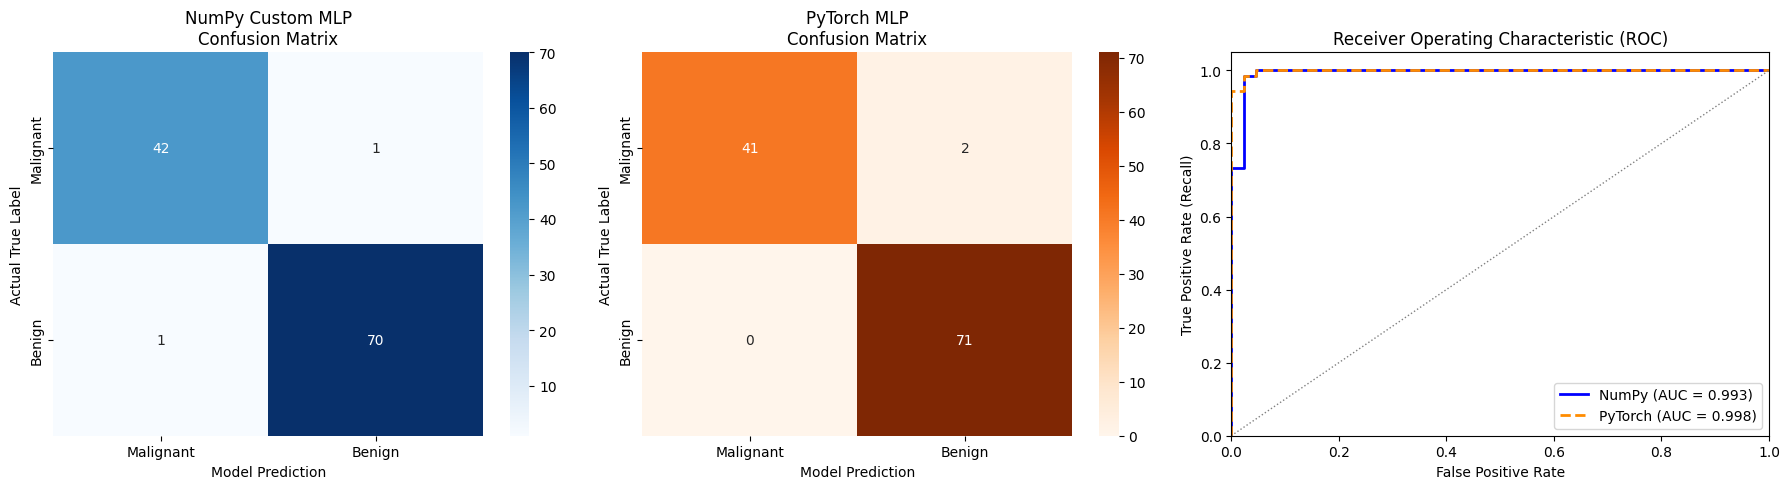

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def visualize_model_performance(Y_true, np_preds_prob, pt_preds_prob):
    # Convert probabilities to strict 1s and 0s
    np_class = (np_preds_prob > 0.5).astype(int).flatten()
    pt_class = (pt_preds_prob > 0.5).astype(int).flatten()

    # Calculate Confusion Matrices
    # Labels: 0 = Malignant, 1 = Benign
    cm_np = confusion_matrix(Y_true, np_class)
    cm_pt = confusion_matrix(Y_true, pt_class)

    # Set up the plot grid
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # --- 1. NumPy Confusion Matrix ---
    sns.heatmap(cm_np, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
                xticklabels=['Malignant', 'Benign'], 
                yticklabels=['Malignant', 'Benign'])
    axes[0].set_title('NumPy Custom MLP\nConfusion Matrix')
    axes[0].set_ylabel('Actual True Label')
    axes[0].set_xlabel('Model Prediction')

    # --- 2. PyTorch Confusion Matrix ---
    sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Oranges', ax=axes[1], 
                xticklabels=['Malignant', 'Benign'], 
                yticklabels=['Malignant', 'Benign'])
    axes[1].set_title('PyTorch MLP\nConfusion Matrix')
    axes[1].set_ylabel('Actual True Label')
    axes[1].set_xlabel('Model Prediction')

    # --- 3. ROC Curve (Comparing Both) ---
    # Calculates the curve of True Positives vs False Positives at different thresholds
    fpr_np, tpr_np, _ = roc_curve(Y_true, np_preds_prob.flatten())
    roc_auc_np = auc(fpr_np, tpr_np)

    fpr_pt, tpr_pt, _ = roc_curve(Y_true, pt_preds_prob.flatten())
    roc_auc_pt = auc(fpr_pt, tpr_pt)

    axes[2].plot(fpr_np, tpr_np, color='blue', lw=2, label=f'NumPy (AUC = {roc_auc_np:.3f})')
    axes[2].plot(fpr_pt, tpr_pt, color='darkorange', lw=2, linestyle='--', label=f'PyTorch (AUC = {roc_auc_pt:.3f})')
    axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':') # Random guess line
    axes[2].set_xlim([0.0, 1.0])
    axes[2].set_ylim([0.0, 1.05])
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate (Recall)')
    axes[2].set_title('Receiver Operating Characteristic (ROC)')
    axes[2].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# --- EXECUTE THE VISUALIZATION ---
# Make sure your models are in evaluation mode
with torch.no_grad():
    pt_predictions_prob = pytorch_model(X_test_pt).numpy()

np_predictions_prob = model.forward(X_test_np, activation="gelu")

# Pass the raw probabilities to the function
visualize_model_performance(Y_test_raw, np_predictions_prob, pt_predictions_prob)

Even though PyTorch had perfect precision (1.00), the NumPy model is clinically better here. In cancer diagnostics, a False Positive (telling a healthy patient they might have cancer) just leads to another biopsy. A False Negative (sending a sick patient home) is fatal. The NumPy model's higher Recall (0.98 vs 0.95) means it missed fewer actual malignant tumors.

----

### The Flaws: Why We Abandon MLPs for Other Methods
If the MLP is so powerful, why don't modern LLMs (like me) or self-driving car vision systems use them as their primary architecture? It comes down to two fatal mathematical flaws.

1. Spatial and Sequential Blindness

Imagine you want to train your MLP to recognize a 28×28 pixel image of a handwritten digit.
To feed this into an MLP, you have to "flatten" the 2D grid into a 1D line of 784 pixels.
By flattening the image, you destroy all spatial relationships. The MLP has no idea that pixel #1 is right next to pixel #29 (the pixel directly below it in the 2D grid). It treats the top-left pixel and the bottom-right pixel exactly the same way it treated "cell radius" and "cell texture" in your clinical data—as completely unrelated features.
The Solution: We use Convolutional Neural Networks (CNNs). Instead of flattening the image, a CNN slides a small 2D "window" (a kernel) across the image, looking for edges, shapes, and textures while preserving the geometry.

2. The O(N^2) Parameter Explosion

In a dense MLP, every single neuron connects to every single neuron in the next layer. This causes the math to explode out of control when dealing with high-resolution data.

---
# 👨‍💻 Author
# **Md Saib Hossain**
**AI Engineer • AI / ML / LLM & AI Safety Researcher**  
**Agentic AI Developer • Researcher in Autonomous & Multi-Agent Systems • Advanced Agentic AI Architect**

Designing safe, scalable, and human-centered intelligent systems for real-world healthcare and autonomous AI applications.

<p align="left">
  <a href="mailto:saibhossain5@gmail.com">
    <img src="https://img.shields.io/badge/Email-saibhossain5%40gmail.com-red?style=flat&logo=gmail">
  </a>
  <a href="https://saibhossain.github.io/">
    <img src="https://img.shields.io/badge/Portfolio-Visit-blue?style=flat&logo=google-chrome">
  </a>
  <a href="https://github.com/Saibhossain">
    <img src="https://img.shields.io/badge/GitHub-Profile-black?style=flat&logo=github">
  </a>
  <a href="https://linkedin.com/in/saib-hossain-182834229">
    <img src="https://img.shields.io/badge/LinkedIn-Connect-0A66C2?style=flat&logo=linkedin">
  </a>
</p>